In [22]:
import pandas as pd

df = pd.read_csv('data.csv')
df.head()
len(df)

169909

In [3]:
import pandas as pd
import ast

# Convert string → actual list
df['artists'] = df['artists'].apply(ast.literal_eval)

# One row per artist
df_exploded = df.explode('artists')

# Count songs per artist
artist_counts = df_exploded['artists'].value_counts()

print(artist_counts.head(20))

artists
Francisco Canaro           2234
Эрнест Хемингуэй           1215
Frédéric Chopin            1035
Ludwig van Beethoven        976
Wolfgang Amadeus Mozart     938
Johann Sebastian Bach       868
Эрих Мария Ремарк           781
Igor Stravinsky             739
Frank Sinatra               732
Giuseppe Verdi              691
Billie Holiday              685
Arturo Toscanini            632
Ignacio Corsini             620
Vladimir Horowitz           614
Johnny Cash                 588
New York Philharmonic       582
Bob Dylan                   553
The Rolling Stones          522
The Beach Boys              503
Lata Mangeshkar             502
Name: count, dtype: int64


In [4]:
df_exploded['year']

0         1928
1         1928
1         1928
2         1928
3         1928
          ... 
169906    2020
169906    2020
169907    2020
169907    2020
169908    2020
Name: year, Length: 225456, dtype: int64

In [5]:
print(artist_counts.describe())
print((artist_counts >= 10).sum())

count    27622.00000
mean         8.16219
std         32.47829
min          1.00000
25%          1.00000
50%          2.00000
75%          5.00000
max       2234.00000
Name: count, dtype: float64
4263


In [6]:
ts_songs = df_exploded[df_exploded['artists'].str.lower() == 'taylor swift']

In [7]:
import requests
import time

API_KEY = "f254d1334087cd7a1955a6b411b3a428"
lastfm_data = []

for song in ts_songs['name']:
    url = f"http://ws.audioscrobbler.com/2.0/?method=track.getInfo&api_key={API_KEY}&artist=TAYLOR+SWIFT&track={song}&format=json"
    response = requests.get(url)
    data = response.json()
    
    if 'track' in data:
        playcount = data['track'].get('playcount', None)
        listeners = data['track'].get('listeners', None)
        lastfm_data.append({'name': song, 'playcount': playcount, 'listeners': listeners})
    else:
        lastfm_data.append({'name': song, 'playcount': None, 'listeners': None})
    
    time.sleep(0.25)

In [8]:
lastfm_df = pd.DataFrame(lastfm_data)
lastfm_df.head()

,name,playcount,listeners
0,Tell Me Why,2398205,335981
1,Long Live,5758394,484454
2,Innocent,3505439,381127
3,Dear John,6443675,532235
4,Superman,1912461,221003


In [9]:
ts_songs_enriched = ts_songs.merge(
    lastfm_df,
    on='name',
    how='left'
)

ts_songs_enriched.head()

,id,name,artists,duration_ms,release_date,year,acousticness,danceability,energy,instrumentalness,...,loudness,speechiness,tempo,valence,mode,key,popularity,explicit,playcount,listeners
0,4XrP7vKBjKLEYlRZdb0Ygr,Tell Me Why,Taylor Swift,200560,11/11/08,2008,0.0606,0.601,0.852,0.000003,...,-3.096,0.0386,100.015,0.513,1,7,44,0,2398205,335981
1,4XrP7vKBjKLEYlRZdb0Ygr,Tell Me Why,Taylor Swift,200560,11/11/08,2008,0.0606,0.601,0.852,0.000003,...,-3.096,0.0386,100.015,0.513,1,7,44,0,2398205,335981
2,6XDBA3QWX51lDJ0oZbaJJN,Long Live,Taylor Swift,317947,10/25/10,2010,0.0360,0.418,0.680,0.000076,...,-4.300,0.0346,204.125,0.142,1,7,47,0,5758394,484454
3,6XDBA3QWX51lDJ0oZbaJJN,Long Live,Taylor Swift,317947,10/25/10,2010,0.0360,0.418,0.680,0.000076,...,-4.300,0.0346,204.125,0.142,1,7,47,0,5758394,484454
4,3kfgJql90tzgoxByioAMXR,Innocent,Taylor Swift,302253,10/25/10,2010,0.1860,0.552,0.608,0.000000,...,-5.290,0.0259,134.050,0.170,0,1,47,0,3505439,381127


                                            name       artists  year  \
57                                    Tim McGraw  Taylor Swift  2006   
196                       A Perfectly Good Heart  Taylor Swift  2006   
168                              Picture To Burn  Taylor Swift  2006   
58                             Should've Said No  Taylor Swift  2006   
47                               Picture To Burn  Taylor Swift  2006   
..                                           ...           ...   ...   
56                         You Need To Calm Down  Taylor Swift  2019   
23   Soon You’ll Get Better (feat. Dixie Chicks)  Taylor Swift  2019   
44    Death By A Thousand Cuts - Live From Paris  Taylor Swift  2020   
195  Only The Young - Featured in Miss Americana  Taylor Swift  2020   
206            Cornelia Street - Live From Paris  Taylor Swift  2020   

     period_5yr  similarity_to_first5 playcount listeners  
57         2005              0.722283   5517746    555058  
196        2005

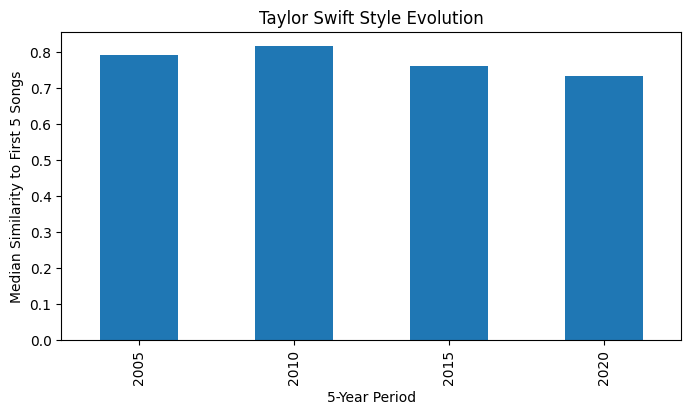

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
ts_songs_final = ts_songs_enriched.copy()

# --- Step 0: Keep only unique songs by track ID ---
ts_demo = ts_songs_final[ts_songs_final['artists'] == 'Taylor Swift'].copy()
ts_demo = ts_demo.drop_duplicates(subset='id').reset_index(drop=True)

# --- Step 1: Add 5-year bins ---
ts_demo['period_5yr'] = (ts_demo['year'] // 5) * 5

# --- Step 2: Scale audio features manually to 0-1 ---
features = ['danceability','energy','acousticness','valence','tempo']
for f in features:
    min_val = ts_demo[f].min()
    max_val = ts_demo[f].max()
    ts_demo[f] = (ts_demo[f] - min_val) / (max_val - min_val)

# --- Step 3: Compute first-5-song baseline ---
first_5 = ts_demo.sort_values('year').head(5)
baseline = first_5[features].mean().values

# --- Step 4: Compute similarity to baseline ---
def similarity_to_baseline(row):
    dist = np.linalg.norm(row.values - baseline)/np.sqrt(len(features))
    return 1 - dist  # higher = more similar

ts_demo['similarity_to_first5'] = ts_demo[features].apply(similarity_to_baseline, axis=1)

# --- Step 5: Keep demo table columns ---
demo_table = ts_demo[['name','artists','year','period_5yr','similarity_to_first5','playcount','listeners']].sort_values('year')
print(demo_table)

# --- Step 6: Optional plot ---
plt.figure(figsize=(8,4))
ts_demo.groupby('period_5yr')['similarity_to_first5'].median().plot(kind='bar')
plt.xlabel('5-Year Period')
plt.ylabel('Median Similarity to First 5 Songs')
plt.title('Taylor Swift Style Evolution')
plt.show()

In [11]:
ts_demo.tail()

,id,name,artists,duration_ms,release_date,year,acousticness,danceability,energy,instrumentalness,...,tempo,valence,mode,key,popularity,explicit,playcount,listeners,period_5yr,similarity_to_first5
202,1B5VzXPqMlvRw0U4HJY3dJ,I Wish You Would,Taylor Swift,207440,10/27/14,2014,0.016072,0.596694,0.931490,0.000049,...,0.356271,0.519392,1,0,51,0,8784356,608298,2010,0.871061
203,2zfgVd034GlUvk7LqBHl6u,I Know Places,Taylor Swift,195707,10/27/14,2014,0.252165,0.512397,0.765625,0.000000,...,0.658052,0.499273,1,0,51,0,8432167,570899,2010,0.870668
204,7I7JbDv63ZJJsSi24DyJrz,Dancing With Our Hands Tied,Taylor Swift,211507,11/10/17,2017,0.062014,0.548760,0.688702,0.000011,...,0.658476,0.263440,0,0,65,0,15540141,675618,2015,0.801339
205,5hQSXkFgbxjZo9uCwd11so,False God,Taylor Swift,200307,8/23/19,2019,0.757932,0.738843,0.242788,0.000147,...,0.082308,0.338326,0,11,69,0,16921095,708959,2015,0.599025
206,3fGnrtrtL1IHSX9t4DKOYf,Cornelia Street - Live From Paris,Taylor Swift,296013,5/18/20,2020,0.595180,0.347107,0.413462,0.000000,...,0.205489,0.285794,1,11,70,0,2851753,218976,2020,0.715733


In [12]:
ts_demo = ts_demo.sort_values('year').reset_index(drop=True)
cumulative_baseline = ts_demo[features].expanding().mean().shift(1)  # previous songs only

ts_demo['similarity_to_previous'] = [
    1 - np.linalg.norm(ts_demo.loc[i, features].values - cumulative_baseline.loc[i].values)/np.sqrt(len(features))
    for i in range(len(ts_demo))
]

In [13]:
period_avg = ts_demo.groupby('period_5yr')[features].transform('mean')
ts_demo['similarity_to_period'] = 1 - np.linalg.norm(ts_demo[features].values - period_avg.values, axis=1)/np.sqrt(len(features))

In [14]:
ts_demo.tail()

,id,name,artists,duration_ms,release_date,year,acousticness,danceability,energy,instrumentalness,...,mode,key,popularity,explicit,playcount,listeners,period_5yr,similarity_to_first5,similarity_to_previous,similarity_to_period
202,6RRNNciQGZEXnqk8SQ9yv5,You Need To Calm Down,Taylor Swift,171360,8/23/19,2019,0.009366,0.791736,0.664663,0.0,...,1,2,83,0,15137583,906518,2015,0.773369,0.760012,0.742945
203,4AYtqFyFbX0Xkc2wtcygTr,Soon You’ll Get Better (feat. Dixie Chicks),Taylor Swift,201587,8/23/19,2019,0.934075,0.233058,0.076923,0.0,...,1,0,69,0,754367,79202,2015,0.459245,0.487556,0.515873
204,3oF7Or7T35yhQbGxbCGvRX,Death By A Thousand Cuts - Live From Paris,Taylor Swift,199067,5/17/20,2020,0.733211,0.482645,0.645433,0.0,...,1,4,65,0,1488739,163208,2020,0.735078,0.719898,0.857887
205,2slqvGLwzZZYsT4K4Y1GBC,Only The Young - Featured in Miss Americana,Taylor Swift,157507,1/31/20,2020,0.002310,0.442975,0.795673,0.0,...,0,5,73,0,2996633,269543,2020,0.869285,0.824337,0.781486
206,3fGnrtrtL1IHSX9t4DKOYf,Cornelia Street - Live From Paris,Taylor Swift,296013,5/18/20,2020,0.595180,0.347107,0.413462,0.0,...,1,11,70,0,2851753,218976,2020,0.715733,0.758356,0.844479


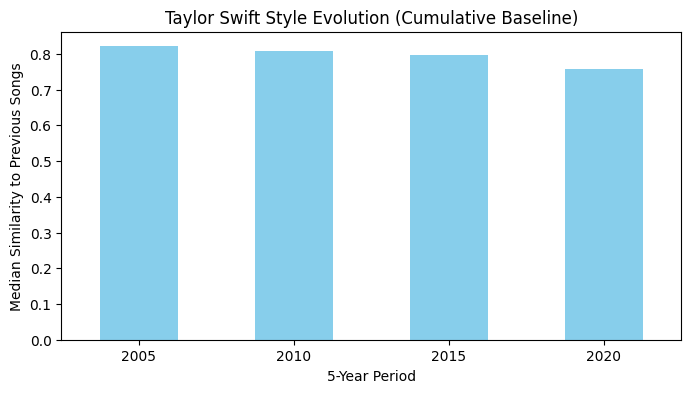

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Step 0: Keep only unique songs ---
ts_demo = ts_songs_final[ts_songs_final['artists'] == 'Taylor Swift'].copy()
ts_demo = ts_demo.drop_duplicates(subset='id').reset_index(drop=True)

# --- Step 1: Add 5-year bins ---
ts_demo['period_5yr'] = (ts_demo['year'] // 5) * 5

# --- Step 2: Normalize audio features manually ---
features = ['danceability','energy','acousticness','valence','tempo']
for f in features:
    min_val = ts_demo[f].min()
    max_val = ts_demo[f].max()
    ts_demo[f] = (ts_demo[f] - min_val) / (max_val - min_val)

# --- Step 3: Compute cumulative baseline similarity ---
ts_demo = ts_demo.sort_values('year').reset_index(drop=True)
similarities = []
for i in range(len(ts_demo)):
    if i == 0:
        similarities.append(1.0)  # first song baseline
    else:
        baseline = ts_demo.loc[:i-1, features].mean().values
        dist = np.linalg.norm(ts_demo.loc[i, features].values - baseline)/np.sqrt(len(features))
        similarities.append(1 - dist)

ts_demo['similarity_to_cumulative'] = similarities

# --- Step 4: Plot similarity over 5-year periods ---
plt.figure(figsize=(8,4))
median_per_period = ts_demo.groupby('period_5yr')['similarity_to_cumulative'].median()
median_per_period.plot(kind='bar', color='skyblue')
plt.xlabel('5-Year Period')
plt.ylabel('Median Similarity to Previous Songs')
plt.title('Taylor Swift Style Evolution (Cumulative Baseline)')
plt.xticks(rotation=0)
plt.show()

In [16]:
ts_demo
ts_demo.columns

Index(['id', 'name', 'artists', 'duration_ms', 'release_date', 'year',
       'acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'mode',
       'key', 'popularity', 'explicit', 'playcount', 'listeners', 'period_5yr',
       'similarity_to_cumulative'],
      dtype='str')

In [17]:
# Current columns
cols = ts_demo.columns.tolist()

# Desired order: put popularity, playcount, listeners after key audio features
new_order = [
    'id','name','artists','year','release_date','duration_ms', 'popularity',
    'acousticness','danceability','energy','instrumentalness','liveness','loudness',
    'speechiness','tempo','valence','mode','key','playcount','listeners',
    'period_5yr','similarity_to_cumulative'
]

ts_demo = ts_demo[new_order]

# Check new order
print(ts_demo.head())

                       id                    name       artists  year  \
0  0Om9WAB5RS09L80DyOfTNa              Tim McGraw  Taylor Swift  2006   
1  1spLfUJxtyVyiKKTegQ2r4  A Perfectly Good Heart  Taylor Swift  2006   
2  1nuk1yTZO3zR8XB8Ofk9q3         Picture To Burn  Taylor Swift  2006   
3  16MVSD0mGI4RMQT83Qzm69       Should've Said No  Taylor Swift  2006   
4  32mVHdy0bi1XKgr0ajsBlG         Picture To Burn  Taylor Swift  2006   

  release_date  duration_ms  popularity  acousticness  danceability    energy  \
0     10/24/06       232107          60      0.592090      0.476033  0.448317   
1     10/24/06       220147          44      0.003392      0.315702  0.760817   
2     10/24/06       175280          57      0.207872      0.611570  0.896635   
3     10/24/06       242200          58      0.010407      0.304132  0.792067   
4     10/24/06       173067          61      0.178000      0.604959  0.912260   

   ...  loudness  speechiness     tempo   valence  mode  key  playcount  \

In [18]:
ts_demo.head()

,id,name,artists,year,release_date,duration_ms,popularity,acousticness,danceability,energy,...,loudness,speechiness,tempo,valence,mode,key,playcount,listeners,period_5yr,similarity_to_cumulative
0,0Om9WAB5RS09L80DyOfTNa,Tim McGraw,Taylor Swift,2006,10/24/06,232107,60,0.592090,0.476033,0.448317,...,-6.462,0.0251,0.053799,0.421035,1,0,5517746,555058,2005,1.000000
1,1spLfUJxtyVyiKKTegQ2r4,A Perfectly Good Heart,Taylor Swift,2006,10/24/06,220147,44,0.003392,0.315702,0.760817,...,-5.726,0.0365,0.630177,0.245557,1,4,2204951,266183,2005,0.591850
2,1nuk1yTZO3zR8XB8Ofk9q3,Picture To Burn,Taylor Swift,2006,10/24/06,175280,57,0.207872,0.611570,0.896635,...,-2.080,0.0322,0.266824,0.830111,1,7,8831160,715060,2005,0.719864
3,16MVSD0mGI4RMQT83Qzm69,Should've Said No,Taylor Swift,2006,10/24/06,242200,58,0.010407,0.304132,0.792067,...,-3.771,0.0289,0.715622,0.473567,0,4,6402329,567309,2005,0.771640
4,32mVHdy0bi1XKgr0ajsBlG,Picture To Burn,Taylor Swift,2006,10/24/06,173067,61,0.178000,0.604959,0.912260,...,-2.098,0.0323,0.266672,0.863641,1,7,8831160,715060,2005,0.786547


In [19]:
import pandas as pd
import numpy as np

# --- Step 0: Keep unique songs ---
ts_demo = ts_songs_final[ts_songs_final['artists'] == 'Taylor Swift'].copy()
ts_demo = ts_demo.drop_duplicates(subset='id').reset_index(drop=True)

# --- Step 1: Normalize audio features manually ---
features = ['danceability','energy','acousticness','valence','tempo']
for f in features:
    min_val = ts_demo[f].min()
    max_val = ts_demo[f].max()
    ts_demo[f] = (ts_demo[f] - min_val) / (max_val - min_val)

# --- Step 2: Similarity to first 5 songs ---
first5 = ts_demo.sort_values('year').head(5)
baseline_first5 = first5[features].mean().values

ts_demo['similarity_to_first5'] = ts_demo[features].apply(
    lambda row: 1 - np.linalg.norm(row.values - baseline_first5)/np.sqrt(len(features)), axis=1
)

# --- Step 3: Similarity to cumulative previous songs ---
ts_demo = ts_demo.sort_values('year').reset_index(drop=True)
similarities_cum = []
for i in range(len(ts_demo)):
    if i == 0:
        similarities_cum.append(1.0)
    else:
        baseline_cum = ts_demo.loc[:i-1, features].mean().values
        dist = np.linalg.norm(ts_demo.loc[i, features].values - baseline_cum)/np.sqrt(len(features))
        similarities_cum.append(1 - dist)
ts_demo['similarity_to_cumulative'] = similarities_cum

# --- Step 4: Similarity to 5-year period average ---
ts_demo['period_5yr'] = (ts_demo['year'] // 5) * 5
period_avg = ts_demo.groupby('period_5yr')[features].transform('mean')
ts_demo['similarity_to_period'] = 1 - np.linalg.norm(ts_demo[features].values - period_avg.values, axis=1)/np.sqrt(len(features))

# --- Step 5: Reorder columns for demo clarity ---
cols_order = [
    'id','name','artists','year','release_date', 'popularity', 'duration_ms',
    'acousticness','danceability','energy','valence','tempo','mode','key',
    'playcount','listeners',
    'period_5yr','similarity_to_first5','similarity_to_cumulative','similarity_to_period'
]
ts_demo = ts_demo[cols_order]

# --- Step 6: Check final demo table ---
print(ts_demo.head())

                       id                    name       artists  year  \
0  0Om9WAB5RS09L80DyOfTNa              Tim McGraw  Taylor Swift  2006   
1  1spLfUJxtyVyiKKTegQ2r4  A Perfectly Good Heart  Taylor Swift  2006   
2  1nuk1yTZO3zR8XB8Ofk9q3         Picture To Burn  Taylor Swift  2006   
3  16MVSD0mGI4RMQT83Qzm69       Should've Said No  Taylor Swift  2006   
4  32mVHdy0bi1XKgr0ajsBlG         Picture To Burn  Taylor Swift  2006   

  release_date  popularity  duration_ms  acousticness  danceability    energy  \
0     10/24/06          60       232107      0.592090      0.476033  0.448317   
1     10/24/06          44       220147      0.003392      0.315702  0.760817   
2     10/24/06          57       175280      0.207872      0.611570  0.896635   
3     10/24/06          58       242200      0.010407      0.304132  0.792067   
4     10/24/06          61       173067      0.178000      0.604959  0.912260   

    valence     tempo  mode  key playcount listeners  period_5yr  \
0  0.4

In [20]:
ts_demo.head()

,id,name,artists,year,release_date,popularity,duration_ms,acousticness,danceability,energy,valence,tempo,mode,key,playcount,listeners,period_5yr,similarity_to_first5,similarity_to_cumulative,similarity_to_period
0,0Om9WAB5RS09L80DyOfTNa,Tim McGraw,Taylor Swift,2006,10/24/06,60,232107,0.592090,0.476033,0.448317,0.421035,0.053799,1,0,5517746,555058,2005,0.722283,1.000000,0.758954
1,1spLfUJxtyVyiKKTegQ2r4,A Perfectly Good Heart,Taylor Swift,2006,10/24/06,44,220147,0.003392,0.315702,0.760817,0.245557,0.630177,1,4,2204951,266183,2005,0.789258,0.591850,0.817925
2,1nuk1yTZO3zR8XB8Ofk9q3,Picture To Burn,Taylor Swift,2006,10/24/06,57,175280,0.207872,0.611570,0.896635,0.830111,0.266824,1,7,8831160,715060,2005,0.842436,0.719864,0.755152
3,16MVSD0mGI4RMQT83Qzm69,Should've Said No,Taylor Swift,2006,10/24/06,58,242200,0.010407,0.304132,0.792067,0.473567,0.715622,0,4,6402329,567309,2005,0.811197,0.771640,0.793915
4,32mVHdy0bi1XKgr0ajsBlG,Picture To Burn,Taylor Swift,2006,10/24/06,61,173067,0.178000,0.604959,0.912260,0.863641,0.266672,1,7,8831160,715060,2005,0.829237,0.786547,0.740234


In [21]:
ts_demo.to_csv('../data/taylor_swift_tracks.csv')

In [ ]:
# Title: Spotify Soundtrack Analyzer - Taylor Swift Style Evolution

In [ ]:
taylor_swift_style_evolution.ipynb